# From Gaussian-Process Performance Models to Composable SNC Guarantees

This notebook demonstrates the complete conceptual pipeline:

1. Generate/prepare service-performance observations.
2. Train a Gaussian Process (GP) for a service's **per-unit processing demand**.
3. Turn the GP prediction interval into a conservative service-rate guarantee.
4. Represent workload with a stochastic arrival envelope.
5. Represent each service with a rate-latency service curve.
6. Compose services using **min-plus convolution**.
7. Derive end-to-end backlog and delay bounds.
8. Evaluate **coverage** and **tightness** on unseen observations.

The notebook is intentionally self-contained. It uses a simple rate-latency SNC model rather than relying on a specialized SNC package, so the mathematical operations are visible.

> Important: this is a pedagogical implementation of the SNC idea. The conversion from a GP prediction distribution to a formal SNC service curve requires assumptions about stationarity, confidence semantics, workload units, and how probabilistic violations are composed.


## 1. Mathematical setup

For service $i$, let $D_i(x)$ be the processing demand per unit of work under configuration $x$.

The GP gives an estimate

$$
D_i(x) \sim \mathcal{N}(\mu_i(x),\sigma_i^2(x))
$$

under the usual GP predictive assumptions.

For a one-sided confidence level $1-\alpha$, construct an upper demand bound

$$
D_i^+(x) = \mu_i(x) + z_{1-\alpha}\sigma_i(x).
$$

Because a larger processing demand means a smaller service rate, convert it to

$$
R_i = \frac{1}{D_i^+(x)}.
$$

A simple rate-latency service curve is

$$
\beta_i(t) = R_i(t-T_i)^+,
$$

where $R_i$ is the guaranteed service rate and $T_i$ is a latency term.

For a tandem

$$
S_1 \rightarrow S_2 \rightarrow \cdots \rightarrow S_n,
$$

SNC composes the service curves using min-plus convolution:

$$
\beta_{\mathrm{e2e}}
=
\beta_1 \otimes \beta_2 \otimes \cdots \otimes \beta_n.
$$

For rate-latency curves this simplifies to

$$
R_{\mathrm{e2e}} = \min_i R_i,
\qquad
T_{\mathrm{e2e}} = \sum_i T_i.
$$

This gives a very intuitive example of composability: **rates are constrained by the bottleneck, while latency terms accumulate.**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(35)

ALPHA = 0.05
Z = norm.ppf(1 - ALPHA)

print(f"Target one-sided coverage: {1-ALPHA:.1%}")
print(f"Gaussian quantile z_(1-alpha): {Z:.3f}")


Target one-sided coverage: 95.0%
Gaussian quantile z_(1-alpha): 1.645


## 2. Example performance data

We model three services in a pipeline. The input `x` represents a service configuration, for example:

- CPU allocation
- quality level
- parallelism
- workload-dependent configuration

The target is **processing demand per unit of work in seconds/unit**.

In your real experiment, replace this synthetic dataset with your measured service observations.


In [2]:
def true_demand(x, service):
    cpu, quality, parallelism = x.T

    if service in ["S1", "S4", "S7"] :
        return (
            0.007
            + 0.010 / cpu
            + 0.004 * quality**1.3
            + 0.001 / parallelism
        )
    if service in ["S2", "S5", "S8"]:
        return (
            0.010
            + 0.004 / cpu
            + 0.006 * quality
            + 0.002 / parallelism
        )
    if service in ["S3", "S6", "S9"]:
        return (
            0.009
            + 0.003 / cpu
            + 0.008 * quality
            + 0.003 / parallelism
        )
    raise ValueError(service)


services = ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9"]

n_train = 80
X_train = np.column_stack([
    np.random.uniform(0.5, 2.0, n_train),   # CPU
    np.random.uniform(0.0, 1.0, n_train),   # quality
    np.random.uniform(1.0, 4.0, n_train),   # parallelism
])

observations = {}

for service in services:
    y_true = true_demand(X_train, service)
    noise = np.random.normal(0, 0.0015, n_train)
    observations[service] = y_true + noise

train_df = pd.DataFrame(X_train, columns=["cpu", "quality", "parallelism"])

for service in services:
    train_df[service] = observations[service]

train_df.head()


,cpu,quality,parallelism,S1,S2,S3,S4,S5,S6,S7,S8,S9
0,1.187082,0.040619,3.112651,0.015075,0.015717,0.011366,0.015722,0.014289,0.010136,0.015933,0.013753,0.010105
1,0.962524,0.221546,1.612548,0.019335,0.018497,0.017237,0.020793,0.019554,0.013280,0.018101,0.018835,0.015703
2,0.847231,0.346833,3.272331,0.018756,0.016213,0.016135,0.020146,0.016639,0.016798,0.022124,0.015227,0.015058
3,0.916137,0.958537,1.843123,0.021947,0.019977,0.020708,0.022806,0.022766,0.021742,0.022804,0.021866,0.019876
4,1.725852,0.473150,3.153118,0.015557,0.014187,0.015816,0.014571,0.016717,0.014317,0.015309,0.016069,0.016606


## 3. Train a GP for each service

The GP estimates both:

- the mean demand $μ(x)$;
- the predictive standard deviation $σ(x)$.

The latter is what allows us to construct an uncertainty-aware guarantee.

This mirrors your existing per-service GP setup.


In [3]:
gps = {}

# TODO: I need to understand the kernel stuff, otherwise I do not learn anything....
for service in services:
    kernel = (
        C(1.0, (1e-2, 1e2))
        * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
        + WhiteKernel(noise_level=0.001**2, noise_level_bounds=(1e-8, 1e-2))
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=3,
        alpha=1e-10,
        random_state=35,
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("gp", gp),
    ])

    model.fit(X_train, observations[service])
    gps[service] = model

    print(service)
    print(model.named_steps["gp"].kernel_)
    print()


S1
0.965**2 * Matern(length_scale=0.657, nu=2.5) + WhiteKernel(noise_level=0.01)

S2
0.974**2 * Matern(length_scale=0.624, nu=2.5) + WhiteKernel(noise_level=0.01)



C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better v

S3
1.01**2 * Matern(length_scale=0.624, nu=2.5) + WhiteKernel(noise_level=0.01)

S4
0.99**2 * Matern(length_scale=0.762, nu=2.5) + WhiteKernel(noise_level=0.01)

S5
1.05**2 * Matern(length_scale=0.625, nu=2.5) + WhiteKernel(noise_level=0.01)

S6
1.02**2 * Matern(length_scale=0.435, nu=2.5) + WhiteKernel(noise_level=0.01)



C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better v

S7
0.937**2 * Matern(length_scale=0.569, nu=2.5) + WhiteKernel(noise_level=0.01)

S8
0.994**2 * Matern(length_scale=0.488, nu=2.5) + WhiteKernel(noise_level=0.01)

S9
1**2 * Matern(length_scale=0.567, nu=2.5) + WhiteKernel(noise_level=0.01)



C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 4. Visualize one GP prediction

The shaded region is a **two-sided** 95% GP interval.

For a performance guarantee we are interested in a **one-sided upper bound on demand**, because:

$$
\text{higher demand}
\Rightarrow
\text{lower service rate}.
$$

Thus the relevant quantity is

$$
D^+(x)=\mu(x)+z_{1-\alpha}\sigma(x).
$$


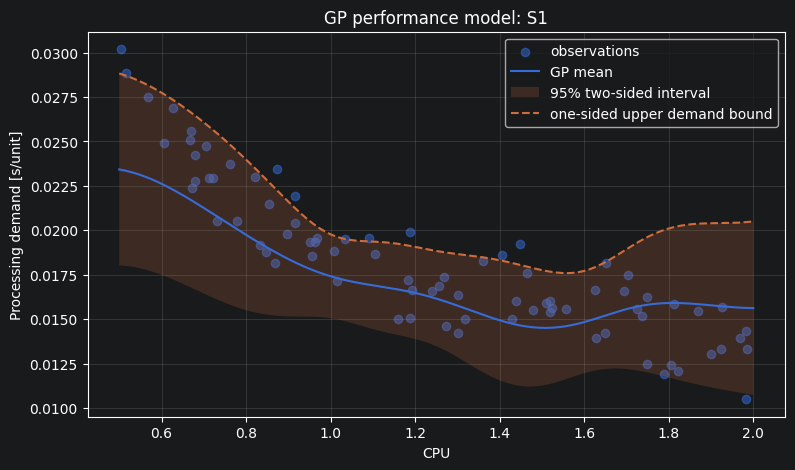

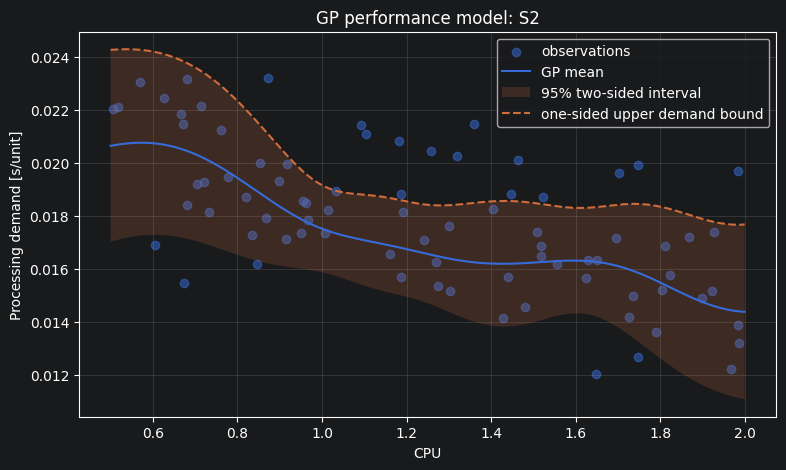

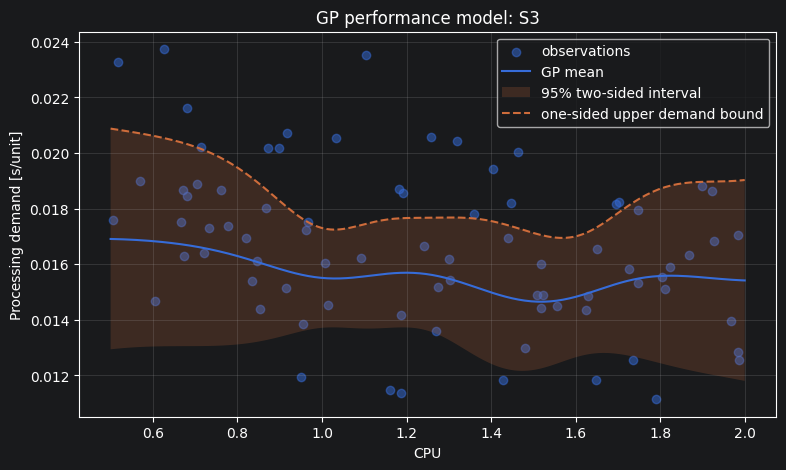

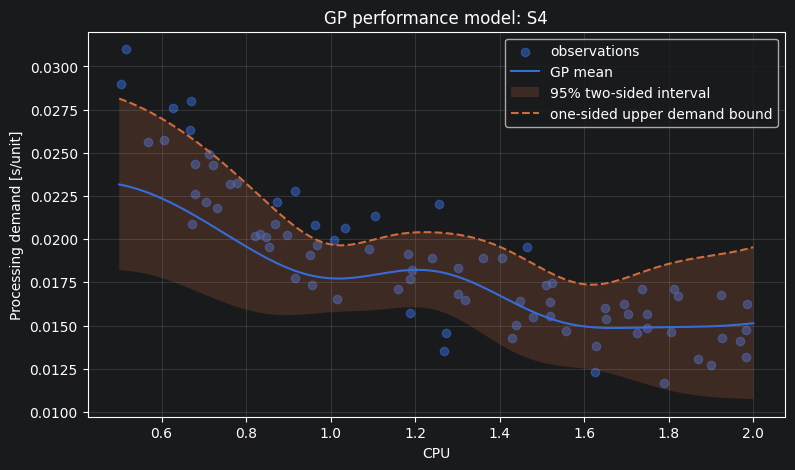

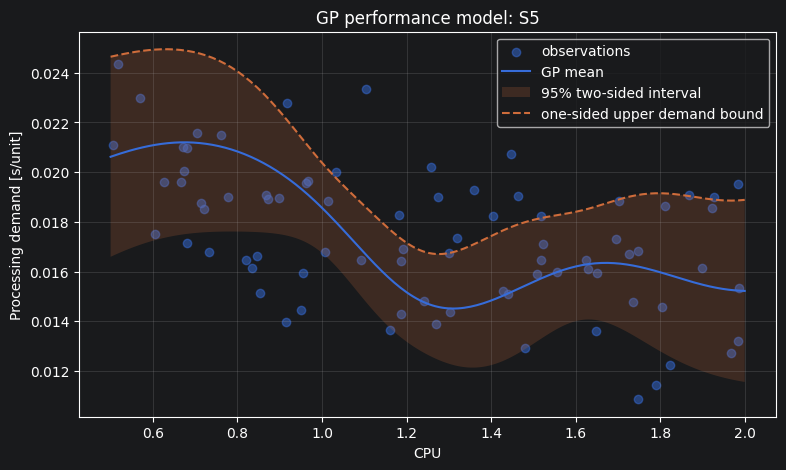

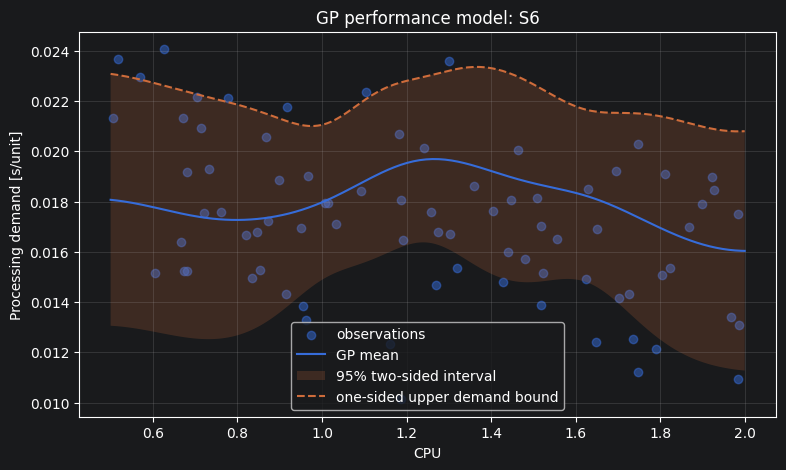

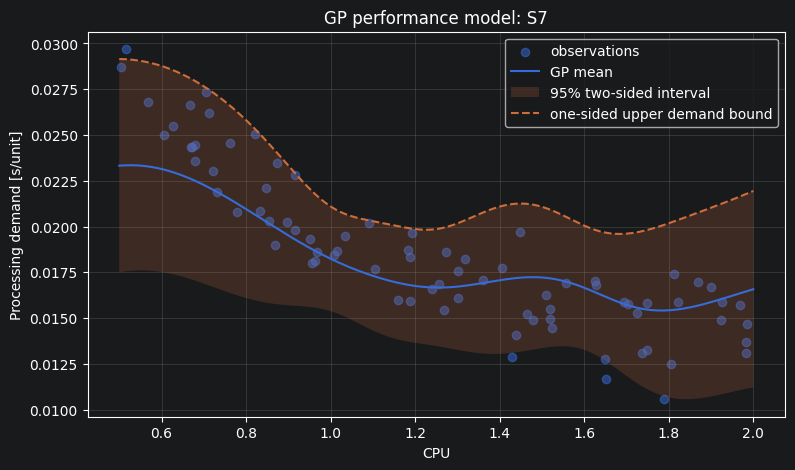

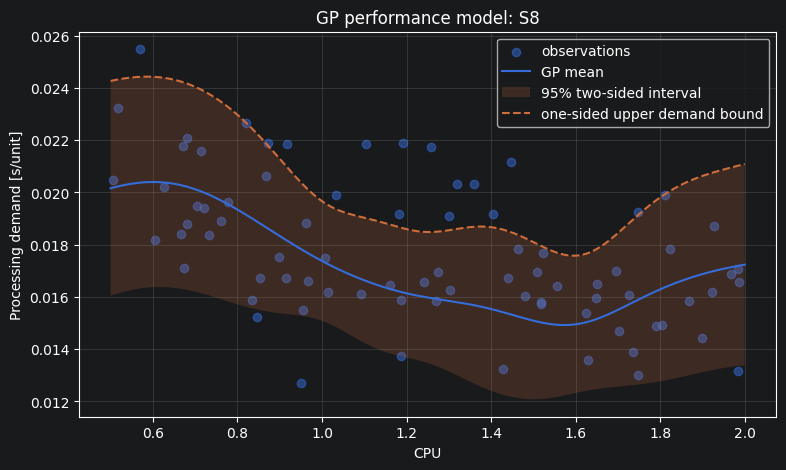

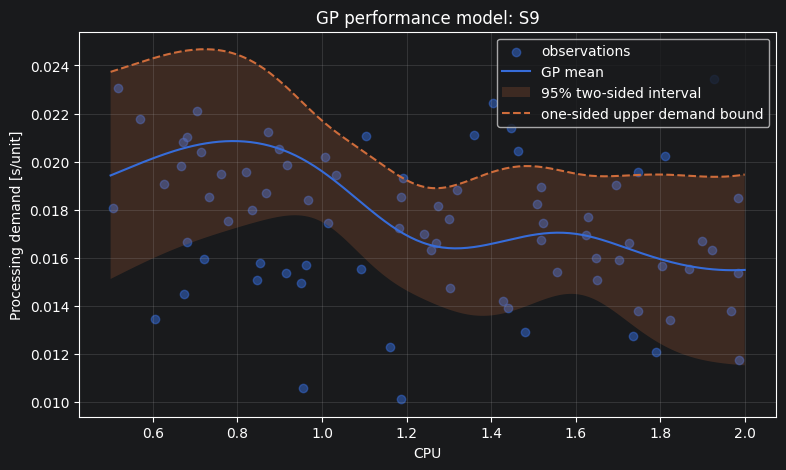

In [4]:
# Hold quality and parallelism fixed and vary CPU.
cpu_grid = np.linspace(0.5, 2.0, 200)
X_plot = np.column_stack([
    cpu_grid,
    np.full_like(cpu_grid, 0.5),
    np.full_like(cpu_grid, 2.0),
])

for service in services:
    mean, std = gps[service].predict(X_plot, return_std=True)

    upper = mean + Z * std
    lower = mean - Z * std

    plt.figure(figsize=(9, 5))
    plt.scatter(X_train[:, 0], observations[service], alpha=0.5, label="observations")
    plt.plot(cpu_grid, mean, label="GP mean")
    plt.fill_between(cpu_grid, lower, upper, alpha=0.2, label="95% two-sided interval")
    plt.plot(cpu_grid, upper, "--", label="one-sided upper demand bound")
    plt.xlabel("CPU")
    plt.ylabel("Processing demand [s/unit]")
    plt.title(f"GP performance model: {service}")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()


## 5. Convert the GP bound into a service-rate guarantee

Suppose the GP gives

$$
D^+(x)=0.012\;\mathrm{s/unit}.
$$

Then the service can conservatively be represented by

$$
R(x)=\frac{1}{D^+(x)}
$$

units/second.

This conversion is important: **SNC works with service offered over time**, whereas your GP naturally predicts a performance quantity for a configuration.

We also introduce a latency term $T$. In a real system this could represent startup, queueing-independent processing latency, communication latency, or another component of the service model.

## Only now is the right time to convert from the latency to the capacity because we have extracted a deterministic bound and now we do not run into risks of distorting the noise anymore


In [5]:
def gp_service_rate(model, X, alpha=0.05):
    mean, std = model.predict(X, return_std=True)
    z = norm.ppf(1 - alpha)

    upper_demand = np.maximum(mean + z * std, 1e-9)
    rate = 1.0 / upper_demand

    return mean, std, upper_demand, rate


# Example configuration
x0 = np.array([[1.5, 0.5, 2.0]])

service_parameters = {}

for service in services:
    mean, std, upper_demand, rate = gp_service_rate(gps[service], x0, ALPHA)

    service_parameters[service] = {
        "mean_demand": float(mean[0]),
        "std_demand": float(std[0]),
        "upper_demand": float(upper_demand[0]),
        "rate": float(rate[0]),
    }

pd.DataFrame(service_parameters).T


,mean_demand,std_demand,upper_demand,rate
S1,0.014515,0.001974,0.017762,56.298609
S2,0.016256,0.001369,0.018508,54.031086
S3,0.014662,0.001498,0.017126,58.389078
S4,0.015581,0.001653,0.018301,54.642813
S5,0.015589,0.001516,0.018083,55.301253
S6,0.018728,0.002392,0.022662,44.126747
S7,0.017222,0.002345,0.021079,47.439484
S8,0.015093,0.001828,0.018099,55.250356
S9,0.016948,0.001737,0.019805,50.492113


## 6. Define rate-latency service curves

For each service:

$$
\beta_i(t)=R_i(t-T_i)^+.
$$

The following implementation evaluates this curve numerically.

The latency values below are illustrative. In a real experiment they would come from measurements or another model.


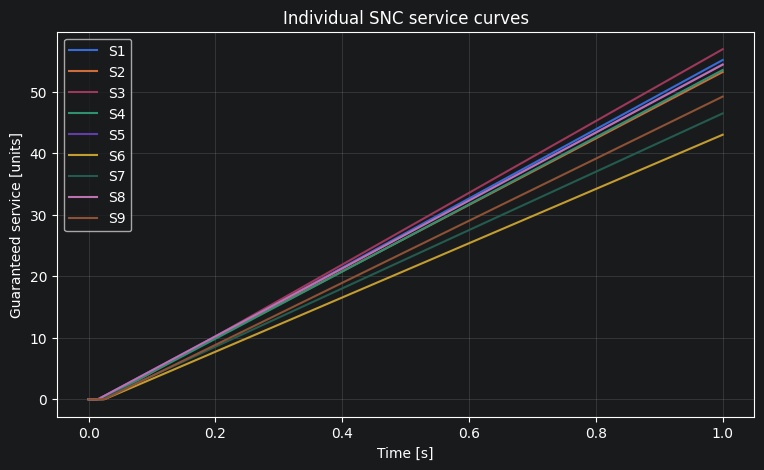

In [6]:
latencies = {
    "S1": 0.020,
    "S2": 0.015,
    "S3": 0.025,
    "S4": 0.020,
    "S5": 0.015,
    "S6": 0.025,
    "S7": 0.020,
    "S8": 0.015,
    "S9": 0.025,
}

def rate_latency_curve(t, rate, latency):
    return rate * np.maximum(t - latency, 0.0)


t = np.linspace(0, 1.0, 500)

plt.figure(figsize=(9, 5))

for service in services:
    p = service_parameters[service]
    beta = rate_latency_curve(t, p["rate"], latencies[service])
    plt.plot(t, beta, label=service)

plt.xlabel("Time [s]")
plt.ylabel("Guaranteed service [units]")
plt.title("Individual SNC service curves")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


## 7. Define an arrival envelope

Suppose the workload entering the chain is bounded by a token-bucket-like arrival curve:

$$
\alpha(t)=\sigma+\rho t.
$$

Here:

- $\rho$ is the long-term arrival rate;
- $\sigma$ is the burst size.

For example, 30 requests/s with a burst of 5 requests.

The SNC system then has:

$$
\text{arrival curve } \alpha
\qquad\text{and}\qquad
\text{service curve } \beta.
$$


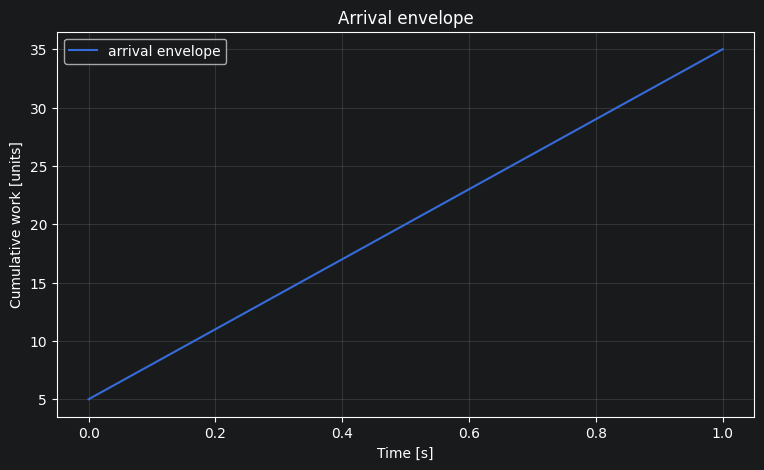

In [7]:
rho = 30.0       # units/s
sigma = 5.0      # units

def arrival_curve(t, rho, sigma):
    return sigma + rho * t

plt.figure(figsize=(9, 5))
plt.plot(t, arrival_curve(t, rho, sigma), label="arrival envelope")
plt.xlabel("Time [s]")
plt.ylabel("Cumulative work [units]")
plt.title("Arrival envelope")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


## 8. Compose the service chain

For arbitrary service curves, SNC uses min-plus convolution:

$$
(\beta_1\otimes\beta_2)(t)
=
\inf_{0\leq s\leq t}
\{
\beta_1(t-s)+\beta_2(s)
\}.
$$

We can implement this directly on a discretized time grid.

For rate-latency curves there is also a closed-form result:

$$
\beta_{1}\otimes\beta_{2}
=
\min(R_1,R_2)
\left(t-(T_1+T_2)\right)^+.
$$

Therefore for the complete chain:

$$
R_{\mathrm{e2e}}=\min_i R_i,
\qquad
T_{\mathrm{e2e}}=\sum_i T_i.
$$


In [8]:
rates = {s: service_parameters[s]["rate"] for s in services}

R_e2e = min(rates.values())
T_e2e = sum(latencies.values())

print("Individual service rates:")
for s in services:
    print(f"  {s}: {rates[s]:.2f} units/s")

print(f"\nEnd-to-end rate:    {R_e2e:.2f} units/s")
print(f"End-to-end latency: {T_e2e:.3f} s")


Individual service rates:
  S1: 56.30 units/s
  S2: 54.03 units/s
  S3: 58.39 units/s
  S4: 54.64 units/s
  S5: 55.30 units/s
  S6: 44.13 units/s
  S7: 47.44 units/s
  S8: 55.25 units/s
  S9: 50.49 units/s

End-to-end rate:    44.13 units/s
End-to-end latency: 0.180 s


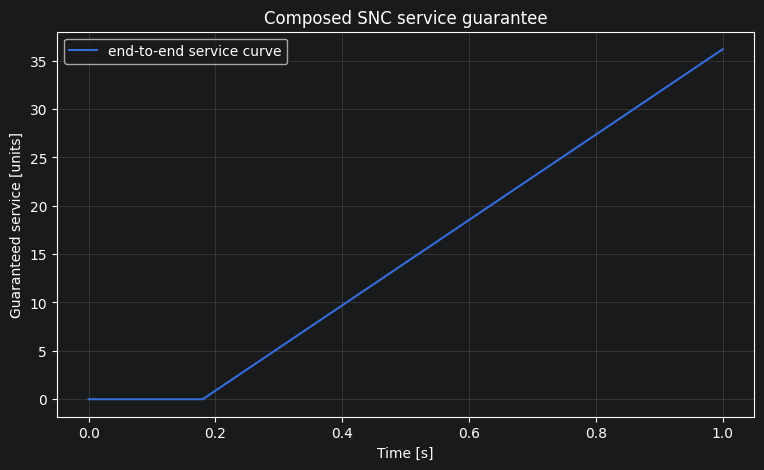

In [9]:
beta_e2e = rate_latency_curve(t, R_e2e, T_e2e)

plt.figure(figsize=(9, 5))
plt.plot(t, beta_e2e, label="end-to-end service curve")
plt.xlabel("Time [s]")
plt.ylabel("Guaranteed service [units]")
plt.title("Composed SNC service guarantee")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


## 9. Check the stability condition

A basic SNC requirement is that the service can keep up with the long-term arrival rate:

$$
\rho < R_{\mathrm{e2e}}.
$$

If

$$
\rho \ge R_{\mathrm{e2e}},
$$

backlog can grow without bound.

This is already useful for your application: a candidate service composition can be rejected if its predicted guaranteed service rate cannot sustain the required workload.


In [10]:
stable = rho < R_e2e

print(f"Arrival rate:       {rho:.2f} units/s")
print(f"Guaranteed service: {R_e2e:.2f} units/s")
print(f"Stable under bound: {stable}")

# TODO: This is actually an important point because usually, a generated application would also come with a performance target and you would say if (1) that is possible at all and (2) how likely this will hold.
#  So the input would be something like [generated_services, service_configurations, target_rate] and the output would be a [yes/no, performance_guarantee, cost]; under the hood this will likely also compute a
#  function that describes the relation of cost (=resources) --> performance guarantee. But all optimization (i.e., selecting/generating services and configurations) is not part of our method; still we can include
#  it as part of the evaluation as use case.

Arrival rate:       30.00 units/s
Guaranteed service: 44.13 units/s
Stable under bound: True


## 10. Derive simple backlog and delay bounds

For a token-bucket arrival curve

$$
\alpha(t)=\sigma+\rho t
$$

and a rate-latency service curve

$$
\beta(t)=R(t-T)^+,
$$

with $R>\rho$, a simple deterministic SNC bound is

$$
B_{\max}\leq \sigma+\rho T.
$$

A corresponding delay bound is

$$
D_{\max}\leq T+\frac{\sigma}{R}.
$$

These equations illustrate the role of the two service-curve parameters:

- increasing **latency** directly increases the delay bound;
- reducing the guaranteed **rate** increases the effect of bursts;
- a tighter service-rate guarantee therefore produces a more useful end-to-end guarantee.


In [11]:
if stable:
    backlog_bound = sigma + rho * T_e2e
    delay_bound = T_e2e + sigma / R_e2e

    print(f"Backlog bound: {backlog_bound:.2f} units")
    print(f"Delay bound:   {delay_bound*1000:.2f} ms")
else:
    print("The SNC stability condition is violated; the simple finite bounds do not apply.")


Backlog bound: 10.40 units
Delay bound:   293.31 ms


## 11. Coverage evaluation

Now we evaluate the GP-derived upper demand bound on **unseen data**.

Coverage is:

$$
\hat C
=
\frac{1}{N}
\sum_{j=1}^{N}
\mathbf{1}
\{D_j\le D_j^+\}.
$$

For a 95% guarantee, we want this to be approximately 95% (or at least 95%, depending on the formal guarantee being targeted).

This is different from tightness: a bound can have high coverage while being unnecessarily conservative.


In [12]:
n_test = 1000

X_test = np.column_stack([
    np.random.uniform(0.5, 2.0, n_test),
    np.random.uniform(0.0, 1.0, n_test),
    np.random.uniform(1.0, 4.0, n_test),
])

coverage_results = []

for service in services:
    true_y = true_demand(X_test, service)
    # Unseen measurement noise
    y = true_y + np.random.normal(0, 0.0015, n_test)

    mean, std, upper, rate = gp_service_rate(gps[service], X_test, ALPHA)

    coverage = np.mean(y <= upper)

    coverage_results.append({
        "service": service,
        "target_coverage": 1 - ALPHA,
        "empirical_coverage": coverage,
    })

coverage_df = pd.DataFrame(coverage_results)
coverage_df


,service,target_coverage,empirical_coverage
0,S1,0.95,0.935
1,S2,0.95,0.925
2,S3,0.95,0.857
3,S4,0.95,0.928
4,S5,0.95,0.879
5,S6,0.95,0.958
6,S7,0.95,0.942
7,S8,0.95,0.920
8,S9,0.95,0.926


## 12. Tightness evaluation

For an upper bound, one simple measure of tightness is the average positive slack:

$$
\mathrm{Slack}
=
\frac{1}{N}
\sum_j
\left(D_j^+-D_j\right).
$$

Another useful metric is **relative slack**:

$$
\mathrm{RelativeSlack}
=
\frac{1}{N}
\sum_j
\frac{D_j^+-D_j}{D_j}.
$$

Lower values mean tighter guarantees.

In a real paper, it is useful to report both coverage and tightness rather than treating either one as sufficient by itself.


In [13]:
tightness_results = []

for service in services:
    y = true_demand(X_test, service) + np.random.normal(0, 0.0015, n_test)
    mean, std, upper, rate = gp_service_rate(gps[service], X_test, ALPHA)

    slack = upper - y
    relative_slack = slack / np.maximum(y, 1e-9)

    tightness_results.append({
        "service": service,
        "coverage": np.mean(y <= upper),
        "mean_slack_ms": np.mean(slack) * 1000,
        "median_slack_ms": np.median(slack) * 1000,
        "mean_relative_slack": np.mean(relative_slack),
    })

tightness_df = pd.DataFrame(tightness_results)
tightness_df


,service,coverage,mean_slack_ms,median_slack_ms,mean_relative_slack
0,S1,0.925,3.514195,3.546501,0.215271
1,S2,0.907,2.802300,2.839204,0.172935
2,S3,0.840,2.267560,2.315420,0.149192
3,S4,0.920,3.433791,3.397796,0.207218
4,S5,0.875,2.705498,2.817184,0.169755
5,S6,0.972,4.049185,3.922125,0.263153
6,S7,0.945,4.358208,4.364705,0.269564
7,S8,0.927,3.246288,3.279451,0.203282
8,S9,0.929,3.423556,3.406872,0.220643


## 13. Coverage vs. tightness

This is the key evaluation idea for your performance-guarantee problem.

A useful guarantee should occupy the regime:

$$
\boxed{
\text{coverage} \geq \text{target}
\quad\text{while minimizing slack}
}
$$

For example:

- 95% coverage with a 1% relative slack is potentially useful.
- 95% coverage with a 100% relative slack is technically safe but conservative.
- 70% coverage with 1% slack is tight but does not satisfy a 95% guarantee.

Thus a natural formulation is:

$$
\min_U \quad \mathrm{Tightness}(U)
$$

subject to

$$
\mathrm{Coverage}(U)\geq 1-\alpha.
$$


## 14. What happens when the chain gets longer?

This is where composability becomes important.

Each service has its own uncertain performance model:

$$
D_i^+(x_i)
\rightarrow
R_i.
$$

SNC then combines them:

$$
R_{\mathrm{e2e}}=\min_i R_i
$$

and

$$
T_{\mathrm{e2e}}=\sum_i T_i.
$$

The following experiment shows how the composed service changes as services are added.


In [14]:
chain_lengths = np.arange(1, len(services) + 1)
rows = []

for n in chain_lengths:
    chain = services[:n]

    R = min(rates[s] for s in chain)
    T = sum(latencies[s] for s in chain)

    if rho < R:
        B = sigma + rho * T
        D = T + sigma / R
    else:
        B = np.inf
        D = np.inf

    rows.append({
        "chain": " -> ".join(chain),
        "R_e2e [units/s]": R,
        "T_e2e [ms]": T * 1000,
        "backlog_bound": B,
        "delay_bound [ms]": D * 1000,
    })

pd.DataFrame(rows)

# TODO: I think that it would actually make a lot of sense to have a single notebook that performs all of this in a simulation. This model applied is the exact same as later for the empirical data.

,chain,R_e2e [units/s],T_e2e [ms],backlog_bound,delay_bound [ms]
0,S1,56.298609,20.0,5.60,108.812142
1,S1 -> S2,54.031086,35.0,6.05,127.539320
2,S1 -> S2 -> S3,54.031086,60.0,6.80,152.539320
3,S1 -> S2 -> S3 -> S4,54.031086,80.0,7.40,172.539320
4,S1 -> S2 -> S3 -> S4 -> S5,54.031086,95.0,7.85,187.539320
5,S1 -> S2 -> S3 -> S4 -> S5 -> S6,44.126747,120.0,8.60,233.309962
6,S1 -> S2 -> S3 -> S4 -> S5 -> S6 -> S7,44.126747,140.0,9.20,253.309962
7,S1 -> S2 -> S3 -> S4 -> S5 -> S6 -> S7 -> S8,44.126747,155.0,9.65,268.309962
8,S1 -> S2 -> S3 -> S4 -> S5 -> S6 -> S7 -> S8 -...,44.126747,180.0,10.40,293.309962


## 15. A useful interpretation for your research

The complete pipeline can be viewed as:

```text
Measured configurations
        |
        v
  Gaussian Process
        |
        | mean + uncertainty
        v
Probabilistic performance bound
        |
        | convert demand -> service rate
        v
   SNC service curve
        |
        | min-plus composition
        v
End-to-end service guarantee
        |
        v
Backlog / delay / SLA guarantee
```

The roles are therefore distinct:

| Component | Question it answers |
|---|---|
| GP | What performance should this service configuration provide? |
| GP uncertainty | How uncertain is that estimate? |
| Upper demand bound | What conservative performance can I rely on? |
| SNC | How can individual service guarantees be composed? |
| Coverage | How often does the guarantee actually hold? |
| Tightness | How much unnecessary slack does the guarantee introduce? |
| E2E SNC bound | What can I guarantee for the whole composition? |

For your work, the interesting research problem is therefore not simply **"train a GP"**. It is the bridge:

$$
\boxed{
\text{data-driven uncertainty model}
\rightarrow
\text{formal probabilistic service envelope}
\rightarrow
\text{composable E2E guarantee}
}
$$

That bridge is where the assumptions need to be made explicit and experimentally validated.


## 16. Important caveats before using this as a formal method

This notebook deliberately simplifies several things.

1. **GP Gaussianity does not automatically imply an SNC guarantee.**  
   A GP predictive interval has a statistical interpretation under its model assumptions. A formal SNC bound requires a suitable stochastic arrival/service characterization.

2. **Independent violations should not be assumed without justification.**  
   When composing probabilistic guarantees, dependence between services can matter. A simple union bound is conservative but does not require independence.

3. **The conversion $R=1/D^+$ assumes a particular work model.**  
   It is appropriate when `D` represents seconds of processing per unit of work. Other performance metrics require a different mapping.

4. **Coverage should be evaluated on genuinely unseen configurations/workloads.**  
   In your setting, this is especially important because the goal is to guarantee configurations that were not directly benchmarked.

5. **Tightness should be measured in the quantity that matters to the SLA.**  
   For latency guarantees, latency slack is more meaningful than raw processing-demand slack. For throughput guarantees, rate slack may be more appropriate.

6. **Composition can amplify conservatism.**  
   Even individually useful bounds can become loose for long service chains. This is precisely why composability and tightness should be evaluated together.
